# **DATASET SIMULADO NO LINEAL**

## **1. LIBRERÍAS**





In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam

import time
resultados_finales = []

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## **2. LIMPIEZA DEL DATASET**

### **2.1 CREACIÓN DEL DATASET Y EXPLORACIÓN DE VARIABLES**


Dimensiones del dataset: (10000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   variable_1  10000 non-null  float64
 1   variable_2  10000 non-null  float64
 2   target      10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


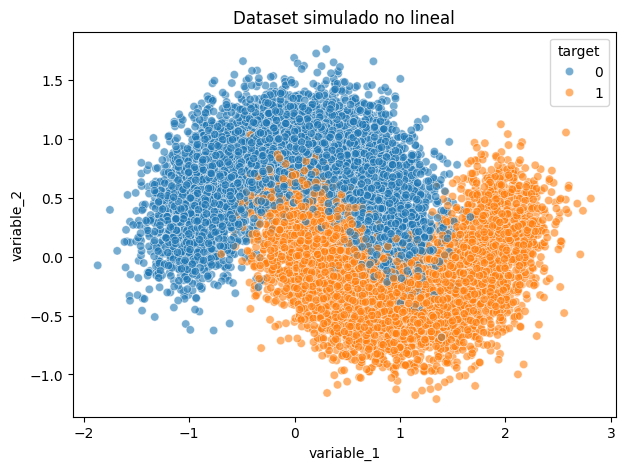

In [3]:
X, y = make_moons(
    n_samples=10000,
    noise=0.25,
    random_state=42
)

df = pd.DataFrame(X, columns=["variable_1", "variable_2"])
df["target"] = y

print("Dimensiones del dataset:", df.shape)
df.info()
df.describe()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="variable_1",
    y="variable_2",
    hue="target",
    alpha=0.6
)

plt.title("Dataset simulado no lineal")
plt.show()

### **2.2 EXPLORACIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS IRRELEVANTES**


In [4]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

,0


### **2.3 SEPARACIÓN ENTRE X E Y (VARIABLE OBJETIVO)**

In [5]:
X = df.drop(columns=["target"])
y = df["target"]
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (10000, 2)
Variable objetivo: (10000,)


### **2.4 DIVISIÓN TRAIN-TEST Y ESCALADO**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (8000, 2)
Test: (2000, 2)


### **2.4 FUNCIÓN DE EVALUACIÓN PARA TODOS LOS MODELOS**

In [7]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": auc
    }

    print(f"\n===== {nombre_modelo} =====")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    return resultados

## **3. REGRESION LOGÍSTICA**

### **3.1 DEFINICIÓN DE PARÁMETROS**

In [8]:
inicio_lr = time.time()
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### **3.2 PREDICCIONES Y MÉTRICAS**

In [9]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]
tiempo_lr = time.time() - inicio_lr

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_prob_lr)

print("===== Regresión logística =====")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc)
print("Tiempo (s):", tiempo_lr)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_lr))

resultados_finales.append({
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC-ROC": auc,
    "Tiempo (s)": tiempo_lr
})

===== Regresión logística =====
Accuracy: 0.864
Precision: 0.8568627450980392
Recall: 0.874
F1-score: 0.8653465346534653
AUC-ROC: 0.9428249999999999
Tiempo (s): 0.08283233642578125

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1000
           1       0.86      0.87      0.87      1000

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



### **3.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

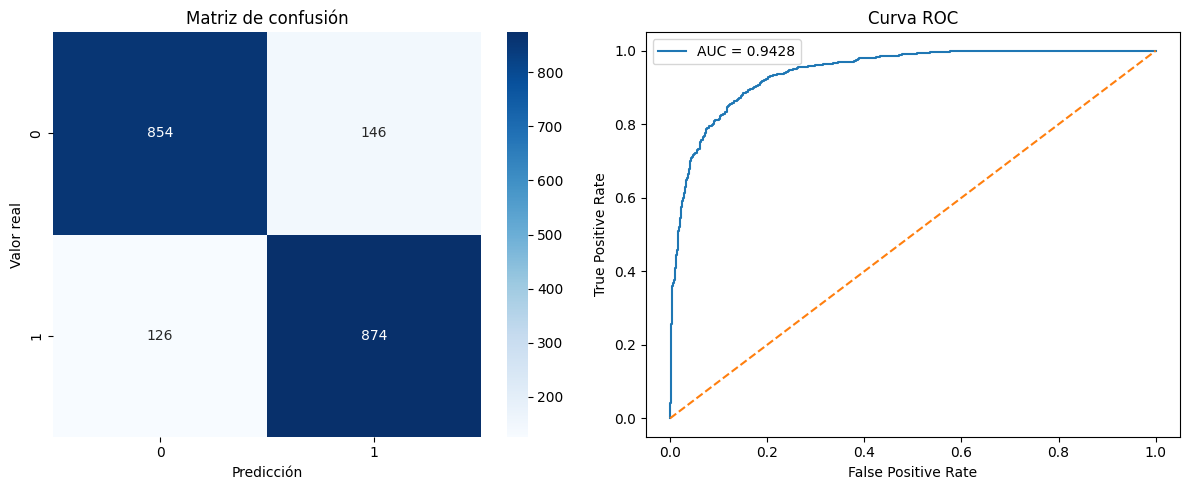

In [10]:
cm = confusion_matrix(y_test, y_pred_lr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc = roc_auc_score(y_test, y_prob_lr)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)
ax[1].plot([0,1], [0,1], linestyle="--")
ax[1].set_title("Curva ROC")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **3.4 IMPORTANCIA DE VARIABLES**

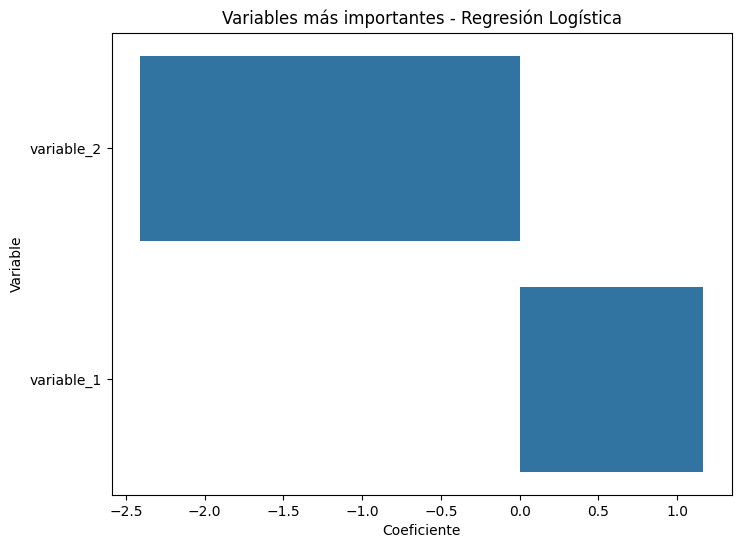

In [11]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_reg.coef_[0]
})

coeficientes["Valor absoluto"] = abs(coeficientes["Coeficiente"])
coeficientes = coeficientes.sort_values(
    by="Valor absoluto",
    ascending=False
)
top10 = coeficientes.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top10,
    x="Coeficiente",
    y="Variable"
)
plt.title("Variables más importantes - Regresión Logística")
plt.show()

## **4. k-NEAREST NEIGHBORS (k-NN)**

### **4.1 DEFINICIÓN DE PARÁMETROS**

In [12]:
inicio_knn = time.time()
resultados_knn = []

for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]

    resultados_knn.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

resultados_knn_df = pd.DataFrame(resultados_knn)

mejor_k = resultados_knn_df.sort_values(by="F1-score", ascending=False).iloc[0]["k"]

print("Mejor valor de k:", mejor_k)

Mejor valor de k: 21.0


### **4.2 PREDICCIONES Y MÉTRICAS**

In [13]:
knn_final = KNeighborsClassifier(n_neighbors=int(mejor_k))
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
y_prob_knn = knn_final.predict_proba(X_test_scaled)[:, 1]
tiempo_knn = time.time() - inicio_knn

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("===== k-NN =====")
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)
print("AUC-ROC:", auc_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

resultados_finales.append({
    "Modelo": "k-NN",
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1-score": f1_knn,
    "AUC-ROC": auc_knn,
    "Tiempo (s)": tiempo_knn
})

===== k-NN =====
Accuracy: 0.9485
Precision: 0.9436201780415431
Recall: 0.954
F1-score: 0.9487817006464445
AUC-ROC: 0.9844510000000001

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1000
           1       0.94      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



### **4.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

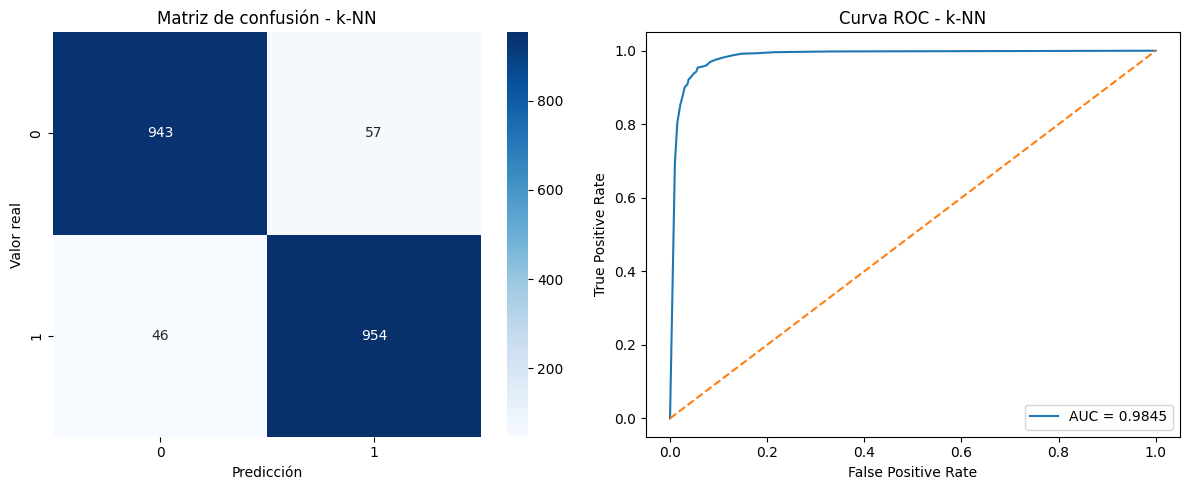

In [14]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - k-NN")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_knn,
    tpr_knn,
    label=f"AUC = {auc_knn:.4f}"
)
ax[1].plot([0,1], [0,1], linestyle="--")
ax[1].set_title("Curva ROC - k-NN")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

## **5. ÁRBOLES DE DECISIÓN**

### **5.1 DEFINICIÓN DE PARÁMETROS**




In [15]:
inicio_tree = time.time()
resultados_tree = []
valores_depth = [3, 5, 10]
valores_leaf = [1, 5, 10]
for depth in valores_depth:
    for leaf in valores_leaf:
        tree = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42
        )
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)
        y_prob = tree.predict_proba(X_test)[:,1]
        resultados_tree.append({
            "max_depth": depth,
            "min_samples_leaf": leaf,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "AUC-ROC": roc_auc_score(y_test, y_prob)
        })
resultados_tree_df = pd.DataFrame(resultados_tree)
mejor_tree = resultados_tree_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]
best_depth = int(mejor_tree["max_depth"])
best_leaf = int(mejor_tree["min_samples_leaf"])
tree_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    random_state=42
)
tree_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, random_state=42)

### **5.2 PREDICCIONES Y MÉTRICAS**

In [16]:
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:,1]
tiempo_tree = time.time() - inicio_tree

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("===== ÁRBOL DE DECISIÓN =====\n")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)
print("AUC-ROC:", auc_tree)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_tree))


resultados_finales.append({
    "Modelo": "Árbol de Decisión",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1-score": f1_tree,
    "AUC-ROC": auc_tree,
    "Tiempo (s)": tiempo_tree
})

===== ÁRBOL DE DECISIÓN =====

Accuracy: 0.942
Precision: 0.9324853228962818
Recall: 0.953
F1-score: 0.9426310583580614
AUC-ROC: 0.9780800000000001

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1000
           1       0.93      0.95      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



### **5.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

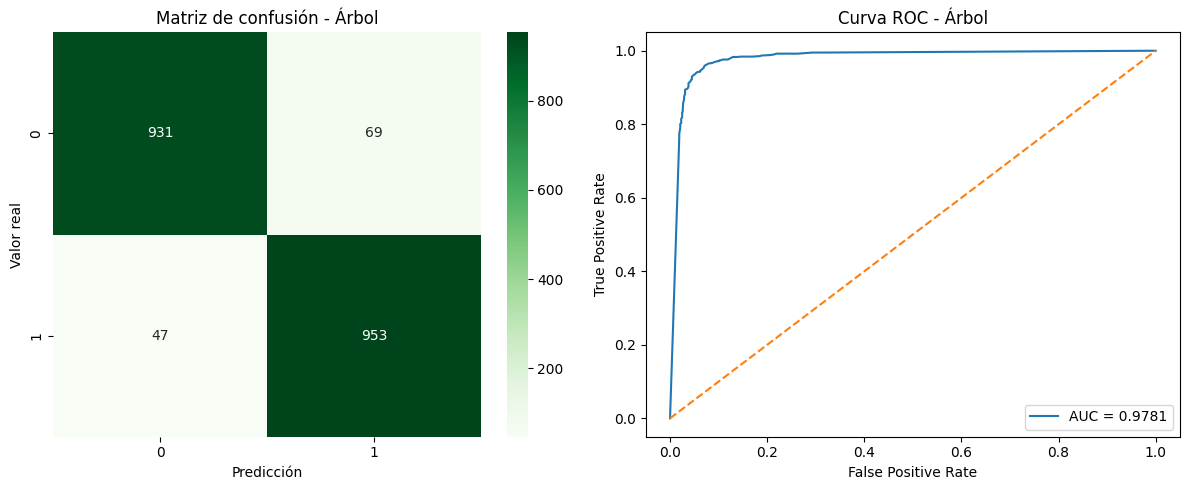

In [17]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# MATRIZ

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Árbol")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

# ROC

ax[1].plot(
    fpr_tree,
    tpr_tree,
    label=f"AUC = {auc_tree:.4f}"
)

ax[1].plot([0,1], [0,1], linestyle="--")

ax[1].set_title("Curva ROC - Árbol")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")

ax[1].legend()

plt.tight_layout()
plt.show()

### **5.4 IMPORTANCIA DE VARIABLES**

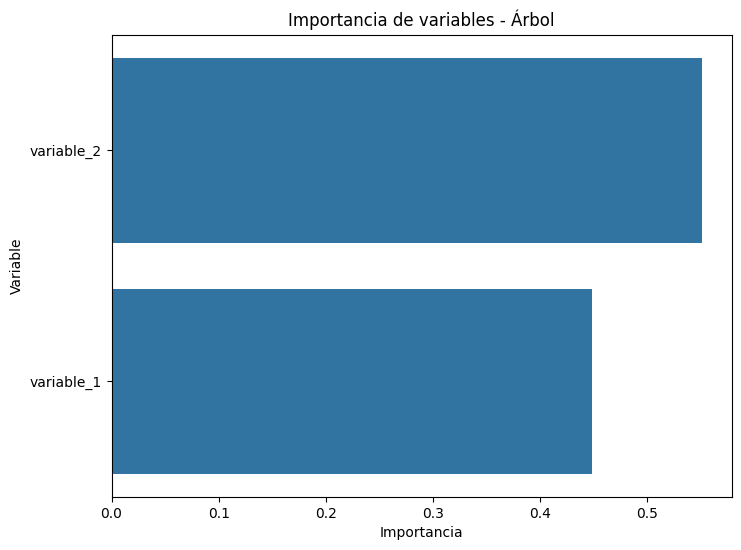

In [18]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": tree.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)
top10 = importancias.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Árbol")

plt.show()

### **5.5 VISUALIZACIÓN**

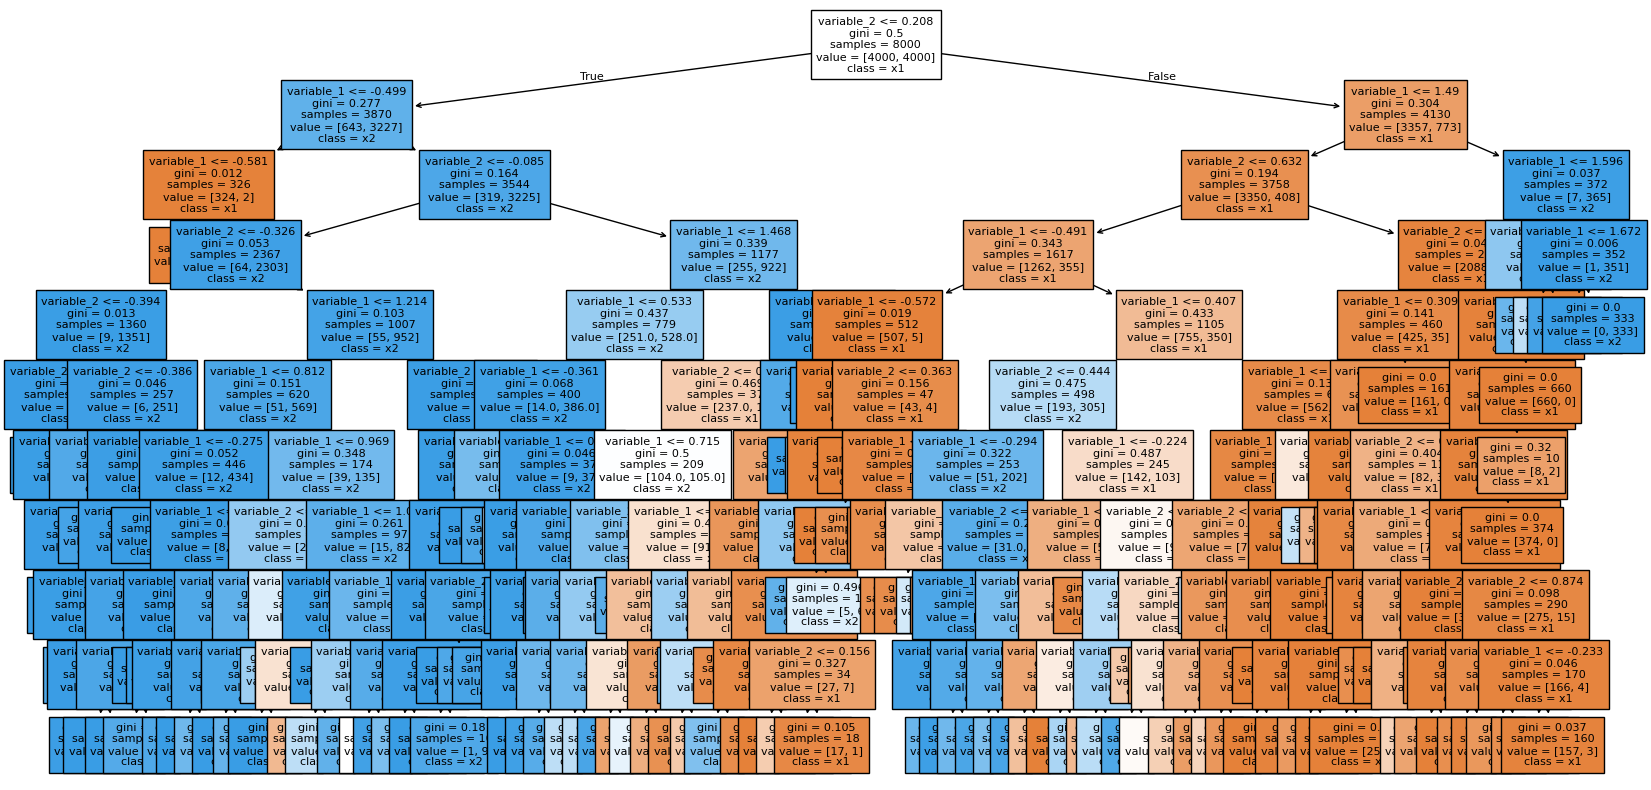

In [19]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["x1", "x2"],
    filled=True,
    fontsize=8
)

plt.show()

## **6. RANDOM FOREST**

### **6.1 DEFINICIÓN DE PARÁMETROS**

In [20]:
inicio_rf = time.time()
resultados_rf = []
valores_estimators = [50, 100, 200, 300, 400]

for n in valores_estimators:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:,1]

    resultados_rf.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

resultados_rf_df = pd.DataFrame(resultados_rf)

mejor_n = resultados_rf_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["n_estimators"]

rf_final = RandomForestClassifier(
    n_estimators=int(mejor_n),
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

### **6.2 PREDICCIONES Y MÉTRICAS**

In [21]:
y_pred_rf = rf_final.predict(X_test)
y_prob_rf = rf_final.predict_proba(X_test)[:, 1]
tiempo_rf = time.time() - inicio_rf

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== RANDOM FOREST =====\n")

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)
print("AUC-ROC:", auc_rf)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_rf))

resultados_finales.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "AUC-ROC": auc_rf,
    "Tiempo (s)": tiempo_rf
})

===== RANDOM FOREST =====

Accuracy: 0.9415
Precision: 0.9341199606686332
Recall: 0.95
F1-score: 0.9419930589985126
AUC-ROC: 0.9838560000000001

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1000
           1       0.93      0.95      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



### **6.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

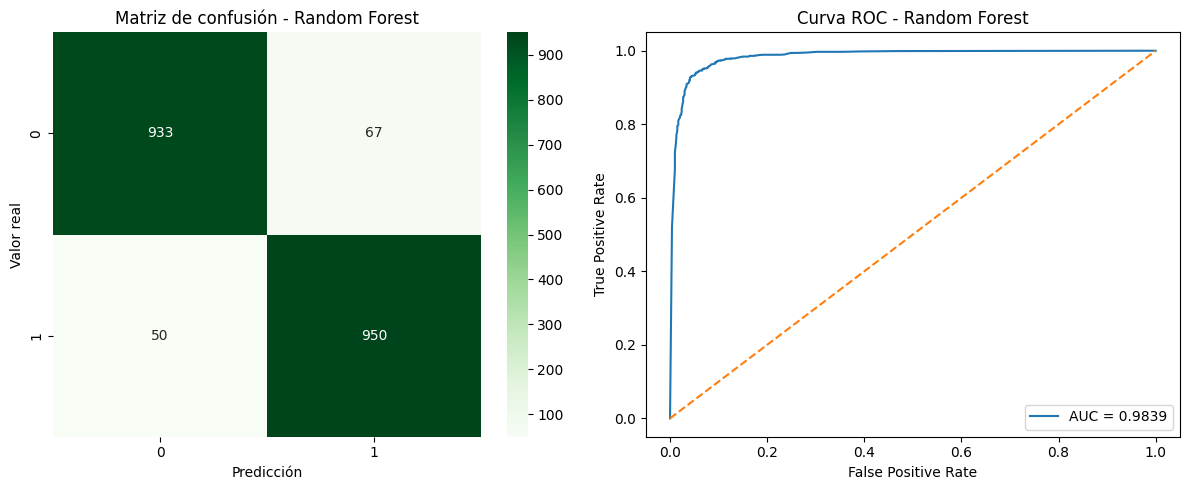

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Random Forest")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {auc_rf:.4f}"
)
ax[1].plot([0, 1], [0, 1], linestyle="--")
ax[1].set_title("Curva ROC - Random Forest")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **6.4 IMPORTANCIA DE VARIABLES**

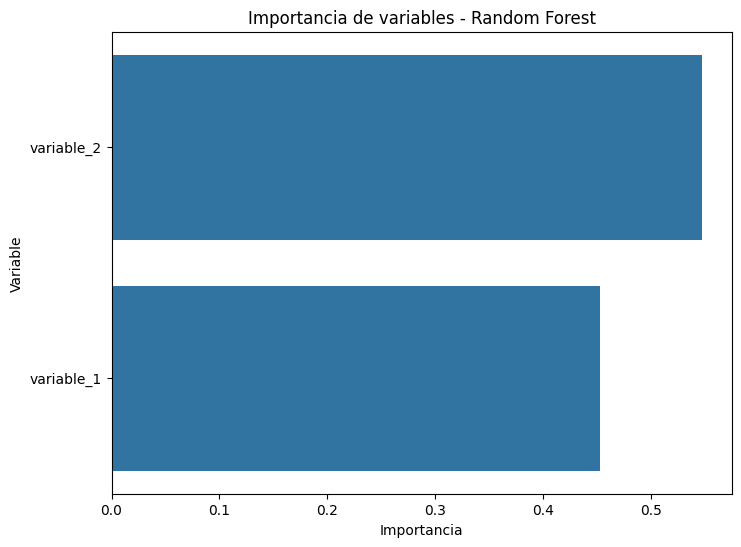

In [23]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

top10_rf = importancias_rf.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_rf,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **7. XGBOOST**

### **7.1 DEFINICIÓN DE PARÁMETROS**

In [24]:
inicio_xgb = time.time()
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# Espacio de hiperparámetros
param_grid_xgb = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5]
}

# Randomized Search
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=50,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(xgb_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros:
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


### **7.2 PREDICCIONES Y MÉTRICAS**

In [25]:
xgb_final = xgb_search.best_estimator_
y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
tiempo_xgb = time.time() - inicio_xgb

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("===== XGBOOST =====\n")

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)
print("AUC-ROC:", auc_xgb)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_xgb))

resultados_finales.append({
    "Modelo": "XGBoost",
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1-score": f1_xgb,
    "AUC-ROC": auc_xgb,
    "Tiempo (s)": tiempo_xgb
})

===== XGBOOST =====

Accuracy: 0.946
Precision: 0.9398422090729783
Recall: 0.953
F1-score: 0.9463753723932473
AUC-ROC: 0.987365

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1000
           1       0.94      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



### **7.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

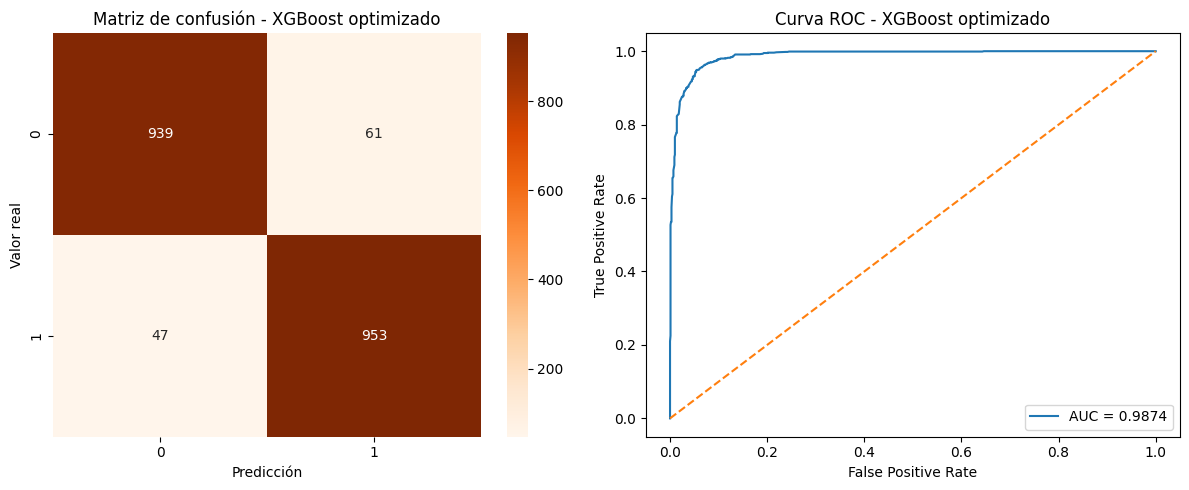

In [26]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - XGBoost optimizado")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {auc_xgb:.4f}"
)
ax[1].plot([0, 1], [0, 1], linestyle="--")
ax[1].set_title("Curva ROC - XGBoost optimizado")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **7.4 IMPORTANCIA DE VARIABLES**

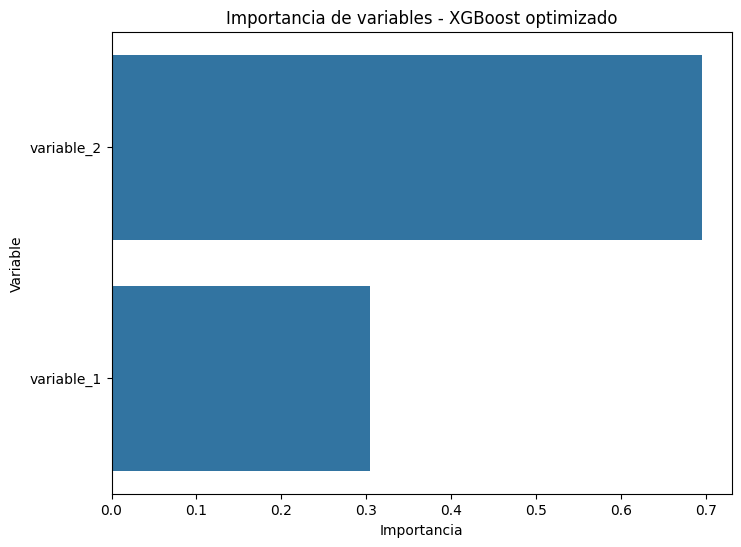

In [27]:
importancias_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

top10_xgb = importancias_xgb.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_xgb,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - XGBoost optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **8. RED NEURONAL**

## **8.1 DIVISIÓN TRAIN-TEST**

In [28]:
inicio_mlp = time.time()
np.random.seed(42)

X_train_nn = X_train_scaled.T
X_test_nn = X_test_scaled.T

y_train_nn = np.array(y_train).reshape(1, -1)
y_test_nn = np.array(y_test).reshape(1, -1)

print("X_train_nn:", X_train_nn.shape)
print("y_train_nn:", y_train_nn.shape)
print("X_test_nn:", X_test_nn.shape)
print("y_test_nn:", y_test_nn.shape)

X_train_nn: (2, 8000)
y_train_nn: (1, 8000)
X_test_nn: (2, 2000)
y_test_nn: (1, 2000)


## **8.2 FUNCIONES DE ACTIVACIÓN**

In [29]:
def sigmoid(Z):
    A = 1 / (1 + np.exp(-Z))
    return A, Z

def relu(Z):
    A = np.maximum(0, Z)
    return A, Z

def relu_backward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def sigmoid_backward(dA, Z):
    A = 1 / (1 + np.exp(-Z))
    dZ = dA * A * (1 - A)
    return dZ

## **8.3 DEFINICIÓN DE FUNCIONES:**


*   Inizialización de parámetros
*   Propagación hacia delante


*   Función de coste
*   Propagación hacia atrás

*   Actualización de parámetros
*   Desarrollo del modelo


*   Función de predicción








In [30]:
# 1. Inizialización de parámetros

def initialize_parameters_he(layer_dims):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters["W" + str(l)] = np.random.randn(
            layer_dims[l],
            layer_dims[l-1]
        ) * np.sqrt(2 / layer_dims[l-1])
        parameters["b" + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

# 2. Propagación hacia delante

def linear_forward(A_prev, W, b):
    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)
    return Z, cache

def linear_activation_forward(A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "relu":
        A, activation_cache = relu(Z)
    elif activation == "sigmoid":
        A, activation_cache = sigmoid(Z)
    cache = (linear_cache, activation_cache)
    return A, cache

def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(
            A_prev,
            parameters["W" + str(l)],
            parameters["b" + str(l)],
            activation="relu"
        )
        caches.append(cache)
    AL, cache = linear_activation_forward(
        A,
        parameters["W" + str(L)],
        parameters["b" + str(L)],
        activation="sigmoid"
    )
    caches.append(cache)
    return AL, caches

# 3. Función de coste

def compute_cost(AL, Y, parameters=None, lambd=0):
    m = Y.shape[1]
    epsilon = 1e-8
    cross_entropy_cost = -1/m * np.sum(
        Y * np.log(AL + epsilon) + (1 - Y) * np.log(1 - AL + epsilon)
    )
    L2_cost = 0
    if lambd > 0 and parameters is not None:
        L = len(parameters) // 2
        for l in range(1, L + 1):
            L2_cost += np.sum(np.square(parameters["W" + str(l)]))
        L2_cost = (lambd / (2 * m)) * L2_cost
    cost = cross_entropy_cost + L2_cost
    return np.squeeze(cost)

# 4. Propagación hacia detrás

def linear_backward(dZ, cache, lambd=0):
    A_prev, W, b = cache
    m = A_prev.shape[1]
    dW = 1/m * np.dot(dZ, A_prev.T) + (lambd / m) * W
    db = 1/m * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation, lambd=0):
    linear_cache, activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    dA_prev, dW, db = linear_backward(dZ, linear_cache, lambd)
    return dA_prev, dW, db

def L_model_backward(AL, Y, caches, lambd=0):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    epsilon = 1e-8

    # Derivada inicial respecto a AL
    dAL = - (np.divide(Y, AL + epsilon) - np.divide(1 - Y, 1 - AL + epsilon))

    # Última capa: SIGMOID
    current_cache = caches[L - 1]
    dA_prev, dW, db = linear_activation_backward(
        dAL,
        current_cache,
        activation="sigmoid",
        lambd=lambd
    )
    grads["dA" + str(L-1)] = dA_prev
    grads["dW" + str(L)] = dW
    grads["db" + str(L)] = db

    # Capas ocultas: RELU
    for l in reversed(range(L - 1)):
        current_cache = caches[l]
        dA_prev, dW, db = linear_activation_backward(
            grads["dA" + str(l + 1)],
            current_cache,
            activation="relu",
            lambd=lambd
        )
        grads["dA" + str(l)] = dA_prev
        grads["dW" + str(l + 1)] = dW
        grads["db" + str(l + 1)] = db
    return grads

# 5. Actualización de parámetros

def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]
    return parameters

# 6. Modelo completo

def L_layer_model(
    X,
    Y,
    layer_dims,
    learning_rate,
    num_iterations,
    lambd,
    print_cost=True
):
    np.random.seed(42)
    costs = []
    parameters = initialize_parameters_he(layer_dims)
    for i in range(num_iterations):

        # Forward propagation
        AL, caches = L_model_forward(X, parameters)

        # Coste
        cost = compute_cost(AL, Y, parameters, lambd)

        # Backpropagation
        grads = L_model_backward(AL, Y, caches, lambd)

        # Actualización de parámetros
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration {i}: {cost}")
    return parameters, costs

# 7. Función de predicción

def predict(X, parameters, threshold):
    AL, _ = L_model_forward(X, parameters)
    predictions = (AL >= threshold).astype(int)
    return predictions, AL

## **8.4 BÚSQUEDA DE HIPERPARÁMETROS**

In [31]:
resultados_mlp = []

arquitecturas = [
    [X_train_nn.shape[0], 8, 4, 1],
    [X_train_nn.shape[0], 16, 8, 1],
    [X_train_nn.shape[0], 32, 16, 1]
]

learning_rates = [0.01, 0.001]
num_iterations_list = [2000, 3000]
lambdas = [0, 0.01]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for arquitectura in arquitecturas:
    for lr in learning_rates:
        for num_iter in num_iterations_list:
            for lambd_value in lambdas:

                parameters_temp, costs_temp = L_layer_model(
                    X_train_nn,
                    y_train_nn,
                    layer_dims=arquitectura,
                    learning_rate=lr,
                    num_iterations=num_iter,
                    lambd=lambd_value,
                    print_cost=False
                )

                # Probabilidades del modelo
                _, y_prob_temp_nn = predict(
                    X_test_nn,
                    parameters_temp,
                    threshold=0.5
                )

                y_prob_temp = y_prob_temp_nn.ravel()

                # Probar distintos thresholds sobre las mismas probabilidades
                for threshold in thresholds:

                    y_pred_temp = (y_prob_temp >= threshold).astype(int)

                    resultados_mlp.append({
                        "Arquitectura": str(arquitectura),
                        "Learning Rate": lr,
                        "Iteraciones": num_iter,
                        "Lambda L2": lambd_value,
                        "Threshold": threshold,
                        "Accuracy": accuracy_score(y_test, y_pred_temp),
                        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
                        "Recall": recall_score(y_test, y_pred_temp, zero_division=0),
                        "F1-score": f1_score(y_test, y_pred_temp, zero_division=0),
                        "AUC-ROC": roc_auc_score(y_test, y_prob_temp),
                        "Coste final": costs_temp[-1]
                    })

resultados_mlp_df = pd.DataFrame(resultados_mlp)

resultados_mlp_df.sort_values(
    by="F1-score",
    ascending=False
).head(5)

,Arquitectura,Learning Rate,Iteraciones,Lambda L2,Threshold,Accuracy,Precision,Recall,F1-score,AUC-ROC,Coste final
17,"[2, 8, 4, 1]",0.01,3000,0.01,0.5,0.902,0.883588,0.926,0.904297,0.948101,0.286064
12,"[2, 8, 4, 1]",0.01,3000,0.00,0.5,0.902,0.883588,0.926,0.904297,0.948101,0.286045
91,"[2, 32, 16, 1]",0.01,3000,0.00,0.4,0.897,0.873120,0.929,0.900194,0.966173,0.240773
96,"[2, 32, 16, 1]",0.01,3000,0.01,0.4,0.897,0.873120,0.929,0.900194,0.966171,0.240833
11,"[2, 8, 4, 1]",0.01,3000,0.00,0.4,0.894,0.858834,0.943,0.898951,0.948101,0.286045


### **8.4.1 Selección del mejor modelo con los hiperparámetros**

In [32]:
mejor_mlp = resultados_mlp_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

print("Mejor configuración encontrada:")
print(mejor_mlp)

best_architecture = eval(mejor_mlp["Arquitectura"])
best_learning_rate = mejor_mlp["Learning Rate"]
best_iterations = int(mejor_mlp["Iteraciones"])
best_lambda = mejor_mlp["Lambda L2"]
best_threshold = mejor_mlp["Threshold"]

Mejor configuración encontrada:
Arquitectura     [2, 8, 4, 1]
Learning Rate            0.01
Iteraciones              3000
Lambda L2                0.01
Threshold                 0.5
Accuracy                0.902
Precision            0.883588
Recall                  0.926
F1-score             0.904297
AUC-ROC              0.948101
Coste final          0.286064
Name: 17, dtype: object


## **8.5 ENTRENAMIENTO DEL MODELO CON LOS HIPERPARÁMETROS**

In [33]:
parameters_mlp, costs_mlp = L_layer_model(
    X_train_nn,
    y_train_nn,
    layer_dims=best_architecture,
    learning_rate=best_learning_rate,
    num_iterations=best_iterations,
    lambd=best_lambda,
    print_cost=True
)

Cost after iteration 0: 0.6415020030743587
Cost after iteration 100: 0.5717683996973021
Cost after iteration 200: 0.5259980331178084
Cost after iteration 300: 0.49153488496924225
Cost after iteration 400: 0.46393800025797677
Cost after iteration 500: 0.44135564424311713
Cost after iteration 600: 0.4225873252584333
Cost after iteration 700: 0.4069131095185235
Cost after iteration 800: 0.3937405000965605
Cost after iteration 900: 0.3825424579961535
Cost after iteration 1000: 0.37295325684851593
Cost after iteration 1100: 0.36462819165266896
Cost after iteration 1200: 0.3573092972611756
Cost after iteration 1300: 0.3508051457185232
Cost after iteration 1400: 0.34496506381826814
Cost after iteration 1500: 0.3396679457614074
Cost after iteration 1600: 0.3347770945934605
Cost after iteration 1700: 0.33020128656361736
Cost after iteration 1800: 0.32590326525826563
Cost after iteration 1900: 0.32183773204353294
Cost after iteration 2000: 0.3179646547345589
Cost after iteration 2100: 0.31424613

## **8.6 CURVA DE COSTE**

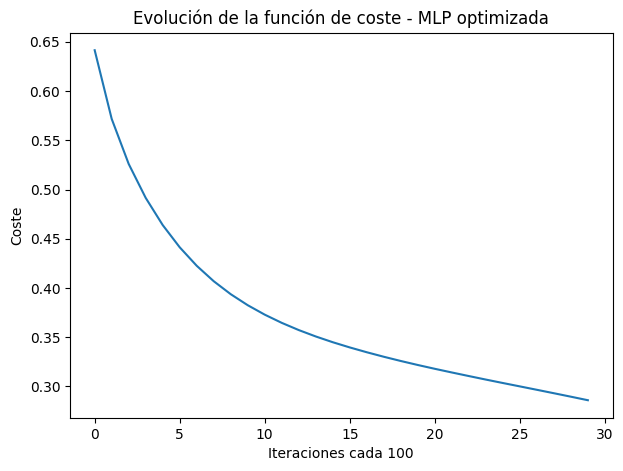

In [34]:
plt.figure(figsize=(7,5))
plt.plot(costs_mlp)
plt.xlabel("Iteraciones cada 100")
plt.ylabel("Coste")
plt.title("Evolución de la función de coste - MLP optimizada")
plt.show()

## **8.7 PREDICCIONES Y MÉTRICAS**

In [35]:
y_pred_mlp_nn, y_prob_mlp_nn = predict(X_test_nn, parameters_mlp, threshold=best_threshold)

y_pred_mlp = y_pred_mlp_nn.ravel()
y_prob_mlp = y_prob_mlp_nn.ravel()
tiempo_mlp = time.time() - inicio_mlp

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp, zero_division=0)
recall_mlp = recall_score(y_test, y_pred_mlp, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, zero_division=0)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

print("===== RED NEURONAL MLP =====\n")

print("Mejor arquitectura:", best_architecture)
print("Learning rate:", best_learning_rate)
print("Iteraciones:", best_iterations)
print("Lambda L2:", best_lambda)
print("Threshold:", best_threshold)

print("\nAccuracy:", accuracy_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1-score:", f1_mlp)
print("AUC-ROC:", auc_mlp)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

resultados_finales.append({
    "Modelo": "Red Neuronal MLP",
    "Accuracy": accuracy_mlp,
    "Precision": precision_mlp,
    "Recall": recall_mlp,
    "F1-score": f1_mlp,
    "AUC-ROC": auc_mlp,
    "Tiempo (s)": tiempo_mlp
})

===== RED NEURONAL MLP =====

Mejor arquitectura: [2, 8, 4, 1]
Learning rate: 0.01
Iteraciones: 3000
Lambda L2: 0.01
Threshold: 0.5

Accuracy: 0.902
Precision: 0.8835877862595419
Recall: 0.926
F1-score: 0.904296875
AUC-ROC: 0.948101

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1000
           1       0.88      0.93      0.90      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



## **8.8 MATRIZ DE CONFUSIÓN Y CURVA ROC**

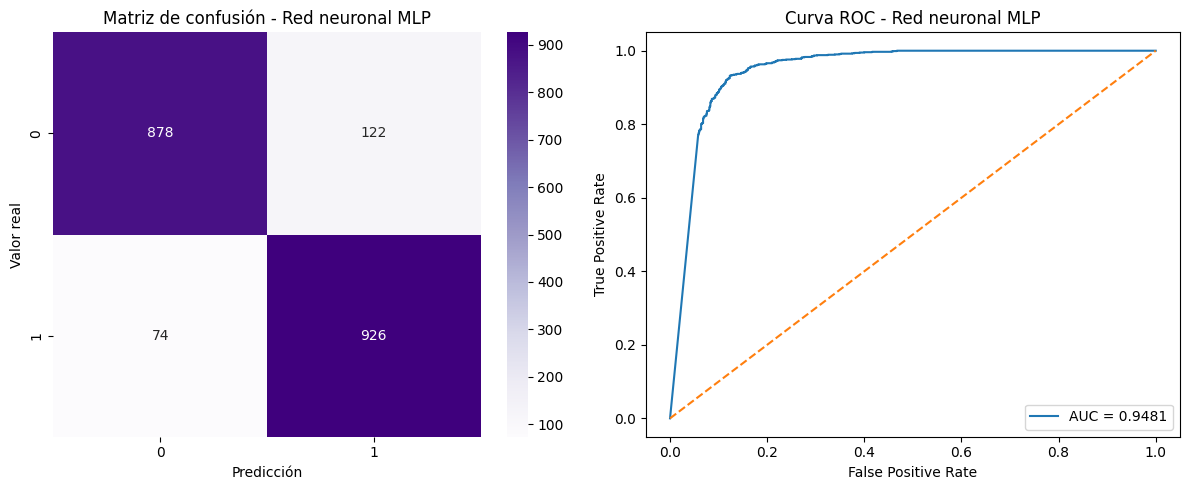

In [36]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_prob_mlp)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Red neuronal MLP")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_mlp,
    tpr_mlp,
    label=f"AUC = {auc_mlp:.4f}"
)

ax[1].plot([0, 1], [0, 1], linestyle="--")

ax[1].set_title("Curva ROC - Red neuronal MLP")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

# **9. COMPARACIÓN DE MODELOS**

In [37]:
tabla_resultados = pd.DataFrame(resultados_finales)

tabla_resultados["Interpretabilidad"] = [
    "Sí",   # Regresión Logística
    "No",   # k-NN
    "Sí",   # Árbol
    "Sí",   # Random Forest
    "Sí",   # XGBoost
    "No"    # Red neuronal
]

tabla_resultados = tabla_resultados.sort_values(
    by="F1-score",
    ascending=False
)

tabla_resultados = tabla_resultados.reset_index(drop=True)

tabla_resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC,Tiempo (s),Interpretabilidad
0,k-NN,0.9485,0.9436,0.954,0.9488,0.9845,2.6069,No
1,XGBoost,0.9460,0.9398,0.953,0.9464,0.9874,40.7228,Sí
2,Árbol de Decisión,0.9420,0.9325,0.953,0.9426,0.9781,0.5189,Sí
3,Random Forest,0.9415,0.9341,0.950,0.9420,0.9839,20.3806,Sí
4,Red Neuronal MLP,0.9020,0.8836,0.926,0.9043,0.9481,493.7352,No
5,Regresión Logística,0.8640,0.8569,0.874,0.8653,0.9428,0.0828,Sí
